In [3]:
!pip install -q transformers datasets accelerate scikit-learn

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from copy import deepcopy

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_scheduler
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Using device: cuda


In [4]:
# LOAD DATASET
print("\n[1] Loading SST-2")
dataset = load_dataset("glue", "sst2")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=128, padding=False)

encoded = dataset.map(preprocess, batched=True, remove_columns=["sentence", "idx"])
encoded = encoded.rename_column("label", "labels")
encoded.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = encoded["train"].select(range(10000))
val_dataset = encoded["validation"]
test_dataset = encoded["validation"]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=data_collator)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


[1] Loading SST-2


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Train: 10000, Val: 872, Test: 872


In [5]:
# HELPER FUNCS
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def evaluate_accuracy(model, dataloader, max_batches=None):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if max_batches and i >= max_batches:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch["labels"]).sum().item()
            total += batch["labels"].size(0)
    return correct / total if total > 0 else 0.0

def measure_latency_ms(model, dataloader, n_batches=50):
    model.eval()
    times = []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_batches:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            start = time.time()
            _ = model(**batch)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append((time.time() - start) * 1000)
    return np.mean(times)

def compute_prr(base, compressed):
    return 100.0 * (base - compressed) / base

def train_model(model, train_loader, val_loader, epochs=2, lr=2e-5):
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    num_training_steps = epochs * len(train_loader)
    scheduler = get_scheduler("linear", optimizer=optimizer, 
                             num_warmup_steps=int(0.1*num_training_steps),
                             num_training_steps=num_training_steps)
    
    best_val_acc, best_state = 0.0, None
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f"    Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / len(train_loader)
        val_acc = evaluate_accuracy(model, val_loader, max_batches=50)
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if best_state:
        model.load_state_dict(best_state)
    model.to(device)
    return best_val_acc

In [6]:
class LowRankLinear(nn.Module):
    def __init__(self, in_features, out_features, rank):
        super().__init__()
        self.rank = min(rank, in_features, out_features)
        # W = U @ V^T =>  output = input @ V @ U^T (transpose for weights)
        self.U = nn.Parameter(torch.randn(out_features, self.rank) / np.sqrt(self.rank))
        self.V = nn.Parameter(torch.randn(in_features, self.rank) / np.sqrt(self.rank))
        self.bias = nn.Parameter(torch.zeros(out_features))
    
    def forward(self, x):
        # x: [batch, seq, in_features]
        # Reconstruct: W = U @ V^T => [out, in]
        # Forward: x @ W^T = x @ (U @ V^T)^T = x @ V @ U^T
        return torch.matmul(torch.matmul(x, self.V), self.U.T) + self.bias

def replace_linear_with_lowrank(model, layer_name, rank=32):
    parts = layer_name.split('.')
    parent = model
    for part in parts[:-1]:
        parent = getattr(parent, part)
    
    original = getattr(parent, parts[-1])
    in_f, out_f = original.in_features, original.out_features
    
    # Create low-rank layer
    lowrank = LowRankLinear(in_f, out_f, rank)
    
    # Initialize pake SVD
    with torch.no_grad():
        W = original.weight.data  # [out, in]
        U, S, Vh = torch.linalg.svd(W, full_matrices=False)
        k = min(rank, len(S))
        lowrank.U.data = U[:, :k] * torch.sqrt(S[:k])  # [out, k]
        lowrank.V.data = (Vh[:k, :] * torch.sqrt(S[:k].unsqueeze(1))).T  # [in, k]
        if original.bias is not None:
            lowrank.bias.data = original.bias.data.clone()
    
    setattr(parent, parts[-1], lowrank)
    return model

def compress_model(model, compress_ffn=True, compress_attn=False, rank=64):
    model = deepcopy(model)
    num_layers = len(model.distilbert.transformer.layer)
    
    if compress_ffn:
        for i in range(num_layers):
            replace_linear_with_lowrank(model, f'distilbert.transformer.layer.{i}.ffn.lin1', rank)
            replace_linear_with_lowrank(model, f'distilbert.transformer.layer.{i}.ffn.lin2', rank)
        print(f"  Compressed {num_layers*2} FFN layers (rank={rank})")
    
    if compress_attn:
        for i in range(num_layers):
            replace_linear_with_lowrank(model, f'distilbert.transformer.layer.{i}.attention.v_lin', rank)
            replace_linear_with_lowrank(model, f'distilbert.transformer.layer.{i}.attention.out_lin', rank)
        print(f"  Compressed {num_layers*2} attention V/O layers (rank={rank})")
    
    return model

In [7]:
# BASELINE
print("\n[2] Training Baseline")
baseline_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

baseline_val_acc = train_model(baseline_model, train_loader, val_loader, epochs=2, lr=2e-5)
baseline_test_acc = evaluate_accuracy(baseline_model, test_loader)
baseline_params = count_parameters(baseline_model)
baseline_latency = measure_latency_ms(baseline_model, test_loader)

print(f"\n[Baseline] Params: {baseline_params/1e6:.2f}M, Acc: {baseline_test_acc:.4f}, Latency: {baseline_latency:.2f}ms")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[2] Training Baseline
    Batch 0/313, Loss: 0.6997
    Batch 100/313, Loss: 0.2940
    Batch 200/313, Loss: 0.1742
    Batch 300/313, Loss: 0.2227
  Epoch 1/2 - Loss: 0.3736, Val Acc: 0.8888
    Batch 0/313, Loss: 0.3018
    Batch 100/313, Loss: 0.1110
    Batch 200/313, Loss: 0.2570
    Batch 300/313, Loss: 0.2414
  Epoch 2/2 - Loss: 0.1803, Val Acc: 0.8933

[Baseline] Params: 66.96M, Acc: 0.8933, Latency: 82.18ms


In [8]:
# TD-FFN
print("\n[3] Building TD-FFN")
td_ffn_model = compress_model(baseline_model, compress_ffn=True, compress_attn=False, rank=64)
td_ffn_params = count_parameters(td_ffn_model)
print(f"  Params: {baseline_params/1e6:.2f}M → {td_ffn_params/1e6:.2f}M ({compute_prr(baseline_params,td_ffn_params):.1f}% reduction)")

print("Fine-tuning TD-FFN")
td_ffn_val_acc = train_model(td_ffn_model, train_loader, val_loader, epochs=2, lr=1e-5)
td_ffn_test_acc = evaluate_accuracy(td_ffn_model, test_loader)
td_ffn_latency = measure_latency_ms(td_ffn_model, test_loader)

print(f"[TD-FFN] Params: {td_ffn_params/1e6:.2f}M, Acc: {td_ffn_test_acc:.4f}, Latency: {td_ffn_latency:.2f}ms")


[3] Building TD-FFN
  Compressed 12 FFN layers (rank=64)
  Params: 66.96M → 41.59M (37.9% reduction)
Fine-tuning TD-FFN
    Batch 0/313, Loss: 0.6456
    Batch 100/313, Loss: 0.3816
    Batch 200/313, Loss: 0.3521
    Batch 300/313, Loss: 0.2870
  Epoch 1/2 - Loss: 0.4648, Val Acc: 0.7890
    Batch 0/313, Loss: 0.3015
    Batch 100/313, Loss: 0.3715
    Batch 200/313, Loss: 0.3347
    Batch 300/313, Loss: 0.3608
  Epoch 2/2 - Loss: 0.3286, Val Acc: 0.7993
[TD-FFN] Params: 41.59M, Acc: 0.7993, Latency: 39.67ms


In [9]:
# TD-FFN + ATTN
print("\n[4] Building TD-FFN+ATTN")
td_full_model = compress_model(baseline_model, compress_ffn=True, compress_attn=True, rank=64)
td_full_params = count_parameters(td_full_model)
print(f"  Params: {baseline_params/1e6:.2f}M → {td_full_params/1e6:.2f}M ({compute_prr(baseline_params,td_full_params):.1f}% reduction)")

print("Fine-tuning TD-FFN+ATTN")
td_full_val_acc = train_model(td_full_model, train_loader, val_loader, epochs=2, lr=1e-5)
td_full_test_acc = evaluate_accuracy(td_full_model, test_loader)
td_full_latency = measure_latency_ms(td_full_model, test_loader)

print(f"[TD-FFN+ATTN] Params: {td_full_params/1e6:.2f}M, Acc: {td_full_test_acc:.4f}, Latency: {td_full_latency:.2f}ms")


[4] Building TD-FFN+ATTN
  Compressed 12 FFN layers (rank=64)
  Compressed 12 attention V/O layers (rank=64)
  Params: 66.96M → 35.69M (46.7% reduction)
Fine-tuning TD-FFN+ATTN
    Batch 0/313, Loss: 0.6844
    Batch 100/313, Loss: 0.4493
    Batch 200/313, Loss: 0.4263
    Batch 300/313, Loss: 0.4318
  Epoch 1/2 - Loss: 0.5245, Val Acc: 0.7420
    Batch 0/313, Loss: 0.3204
    Batch 100/313, Loss: 0.2692
    Batch 200/313, Loss: 0.6970
    Batch 300/313, Loss: 0.2553
  Epoch 2/2 - Loss: 0.3953, Val Acc: 0.7833
[TD-FFN+ATTN] Params: 35.69M, Acc: 0.7833, Latency: 31.29ms


In [10]:
# SUMMARY
print("FINAL RESULTS")
print(f"{'Model':<20} {'Params (M)':<12} {'PRR (%)':<10} {'Latency (ms)':<15} {'Speedup':<10} {'Test Acc (%)'}")
print(f"{'Baseline':<20} {baseline_params/1e6:<12.2f} {0.0:<10.1f} {baseline_latency:<15.2f} {1.00:<10.2f} {baseline_test_acc*100:.2f}")
print(f"{'TD-FFN':<20} {td_ffn_params/1e6:<12.2f} {compute_prr(baseline_params,td_ffn_params):<10.1f} {td_ffn_latency:<15.2f} {baseline_latency/td_ffn_latency:<10.2f} {td_ffn_test_acc*100:.2f}")
print(f"{'TD-FFN+ATTN':<20} {td_full_params/1e6:<12.2f} {compute_prr(baseline_params,td_full_params):<10.1f} {td_full_latency:<15.2f} {baseline_latency/td_full_latency:<10.2f} {td_full_test_acc*100:.2f}")

FINAL RESULTS
Model                Params (M)   PRR (%)    Latency (ms)    Speedup    Test Acc (%)
Baseline             66.96        0.0        82.18           1.00       89.33
TD-FFN               41.59        37.9       39.67           2.07       79.93
TD-FFN+ATTN          35.69        46.7       31.29           2.63       78.33


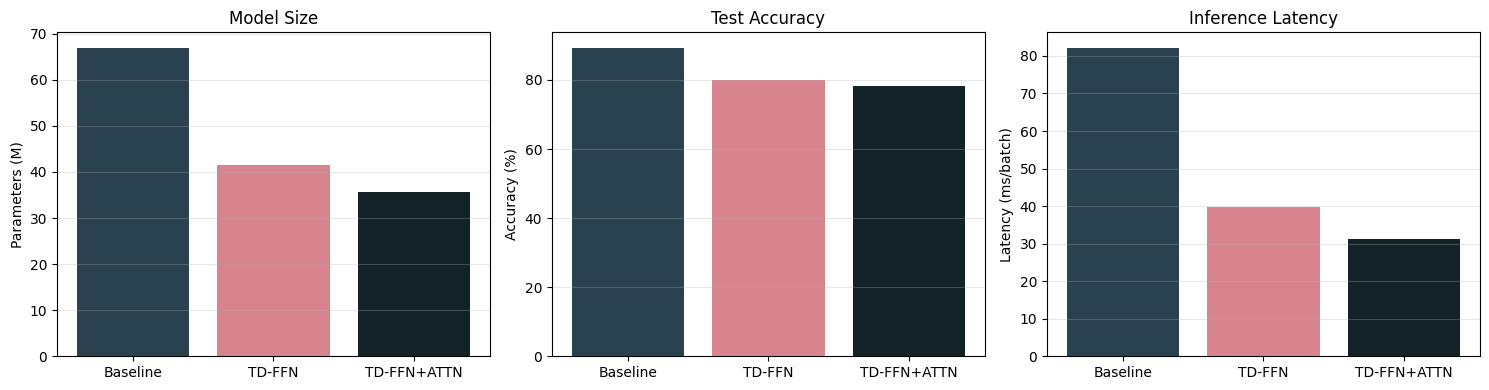

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = ['Baseline', 'TD-FFN', 'TD-FFN+ATTN']
params_list = [baseline_params/1e6, td_ffn_params/1e6, td_full_params/1e6]
acc_list = [baseline_test_acc*100, td_ffn_test_acc*100, td_full_test_acc*100]
latency_list = [baseline_latency, td_ffn_latency, td_full_latency]

axes[0].bar(models, params_list, color=["#2A4150", "#d7848f", "#132227"])
axes[0].set_ylabel('Parameters (M)'); axes[0].set_title('Model Size'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, acc_list, color=["#2A4150", "#d7848f", "#132227"])
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Test Accuracy'); axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, latency_list, color=["#2A4150", "#d7848f", "#132227"])
axes[2].set_ylabel('Latency (ms/batch)'); axes[2].set_title('Inference Latency'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=300)
plt.show()